# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib ipympl

m_e   = 5.9e24         # Earth's mass in kg
m_m   = 7.3e22         # Moon's mass in kg
r_e   = 6378           # Earth's radius in km
dem   = 3.8e8          # Distance between earth and moon
G     = 6.67e-11       # Gravitational Constant
g     = 9.81           # Gravitational acceleration  [m/s^2]
m0    = 2.8e6          # Wet mass of S-1C m_0     [kg]
mf    = 7.5e5          # Dry Mas of S-1C m_f      [kg]
mdot  = 1.3e4          # Burn Rate of S-1C m_dot [kg/s]
ve    = 2.4e3          # Exhaust velocity of Saturn V [m/s]
maplo = 5500           # mass of Apollo [kg]


## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [2]:
def gravp(M, xm, ym, x, y):
    """
    Returns the gravitational potential at location (x,y)
    due to a mass M located at (xm,ym).

    potential = -GM/r

    Parameters
    ----------
    M : 
        Mass of the body (kg)
    xm, ym : 
        Position of the mass (m)
    x, y : 
        Evaluation point(s)

    Returns
    -------
        Gravitational potential
    
    """

    if M <= 0:
        raise ValueError("Mass must be positive")

    r = np.sqrt((x - xm)**2 + (y - ym)**2)

    return np.where(r == 0, np.nan, -G * M / r)

In [3]:
print(gravp(m_e,0,0,r_e,0)) # sanity checking 

-61701160238.31922


2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

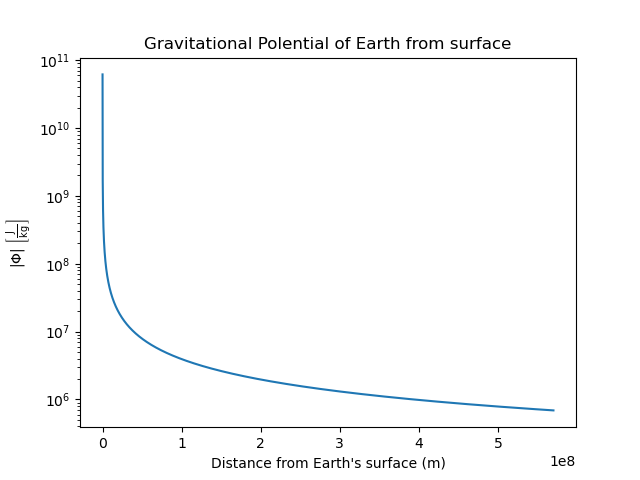

In [4]:
x = np.linspace(1, 1.5*dem, 10000)   # distance from Earth's surface

r = r_e + x                          # convert to distance from Earth's center

P = np.abs(gravp(m_e, 0, 0, r, 0))   # gravitational potential

fig, ax = plt.subplots()

ax.plot(x, P)

#axis label and title
ax.set_title('Gravitational Polential of Earth from surface')
ax.set_xlabel("Distance from Earth's surface (m)")
ax.set_ylabel(r"$|\Phi|\ \left[\mathrm{\frac{J}{kg}}\right]$ ")
ax.set_yscale("log")

plt.show()

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

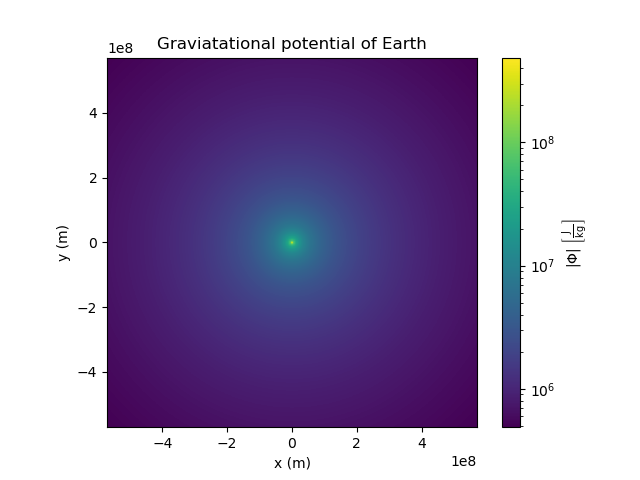

In [5]:
x = np.linspace(-1.5*dem, 1.5*dem, 1000)   #from -1.5*d_EM to 1.5*d_EM in 1000 steps
y = np.linspace(-1.5*dem, 1.5*dem, 1000)   #from -1.5*d_EM to 1.5*d_EM in 1000 steps

x_grid, y_grid = np.meshgrid(x, y)

P2 = gravp(m_e, 0, 0, x_grid, y_grid)

fig1, ax2 = plt.subplots()

ax2.set_aspect("equal")

import matplotlib.colors as colors

mesh = ax2.pcolormesh(
    x_grid,
    y_grid,
    np.abs(P2),
    norm=colors.LogNorm(),  # Logarithmic for color bar
    cmap="viridis"
)

cbar = fig1.colorbar(mesh)
cbar.set_label(r"$|\Phi| \ \left[\mathrm{\frac{J}{kg}}\right]$ ")  # titled color bar, phi 

# Title and axis labels 

ax2.set_title('Graviatational potential of Earth')
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")

plt.show()

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

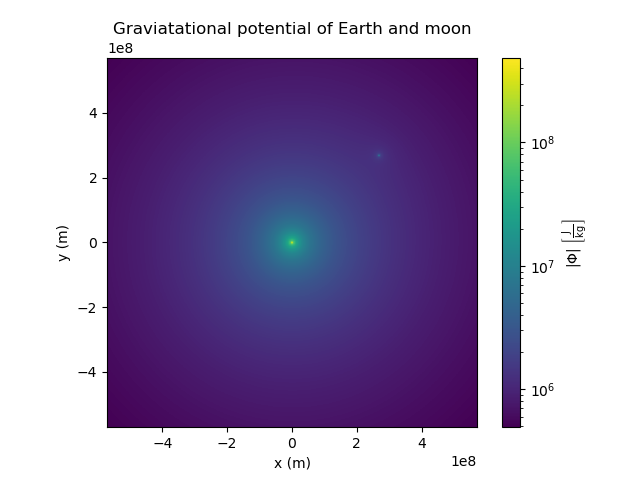

In [6]:
x = np.linspace(-1.5*dem, 1.5*dem, 1000)   #from -1.5*d_EM to 1.5*d_EM in 1000 steps
y = np.linspace(-1.5*dem, 1.5*dem, 1000)   #from -1.5*d_EM to 1.5*d_EM in 1000 steps


x_grid, y_grid = np.meshgrid(x, y)

P2 = gravp(m_e, 0, 0, x_grid, y_grid) + gravp(m_m, dem/np.sqrt(2), dem/np.sqrt(2), x_grid, y_grid) # Potential for both moon and earth

fig2, ax2 = plt.subplots()

ax2.set_aspect("equal") #square aspect

import matplotlib.colors as colors

mesh = ax2.pcolormesh(
    x_grid,
    y_grid,
    np.abs(P2),
    norm=colors.LogNorm(), #plot 2D color-mesh with a logarithmic colorbar
    cmap="viridis"
)

cbar = fig2.colorbar(mesh)
cbar.set_label(r"$|\Phi| \ \left[\mathrm{\frac{J}{kg}}\right]$ ")  # titled color bar, phi 

ax2.set_title('Graviatational potential of Earth and moon')
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")


plt.show()

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

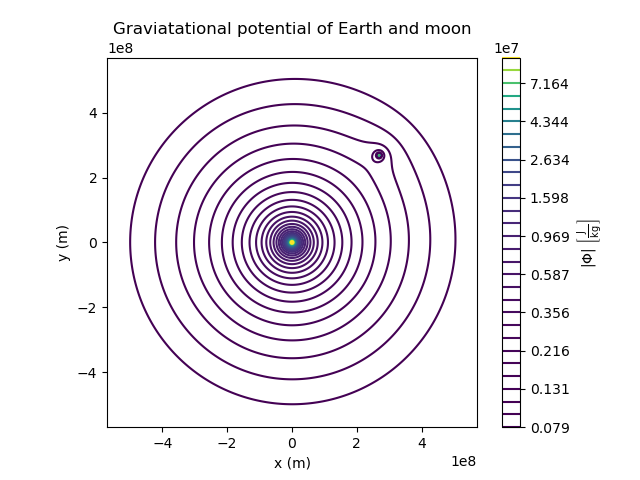

In [7]:
x = np.linspace(-1.5*dem, 1.5*dem, 1000)
y = np.linspace(-1.5*dem, 1.5*dem, 1000)

x_grid, y_grid = np.meshgrid(x, y)

# Combined gravitational potential
Phi = gravp(m_e,0,0,x_grid,y_grid) + \
      gravp(m_m,dem/np.sqrt(2),dem/np.sqrt(2),x_grid,y_grid)

fig3, ax = plt.subplots()

levels = np.logspace(5.9,8,30)   # logarithmic contour spacing

contours = ax.contour(
    x_grid,
    y_grid,
    np.abs(Phi),
    levels=levels,
    #norm=colors.LogNorm()
)

ax.set_title('Graviatational potential of Earth and moon')
ax.set_aspect("equal")

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

cbar = fig3.colorbar(contours)
cbar.set_label(r"$|\Phi| \ \left[\mathrm{\frac{J}{kg}}\right]$ ")  # titled color bar, phi 


plt.show()

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def Force(M, m, x1, y1, x2, y2):
#     M: float,
#     m: float,
#     x1: float,
#     y1: float,
#     x2: float | np.ndarray,
#     y2: float | np.ndarray
# ) -> tuple:
    """
    Compute the gravitational force exerted by mass M on mass m.

    Parameters
    ----------
    M : float
        Mass of the first body (kg)
    m : float
        Mass of the second body (kg)
    x1, y1 : float
        Position of the first mass
    x2, y2 : float or ndarray
        Position of the second body

    Returns
    -------
    Fx, Fy : float or ndarray
        Components of the gravitational force on m
    """

    if M <= 0 or m <= 0:
        raise ValueError("Masses must be positive")

    rx = x2 - x1
    ry = y2 - y1

    r = np.sqrt(rx**2 + ry**2)

    Fmag = np.where(r == 0, np.nan, -G * M * m / r**2)

    Fx = Fmag * (rx / r)
    Fy = Fmag * (ry / r)

    return Fx, Fy

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

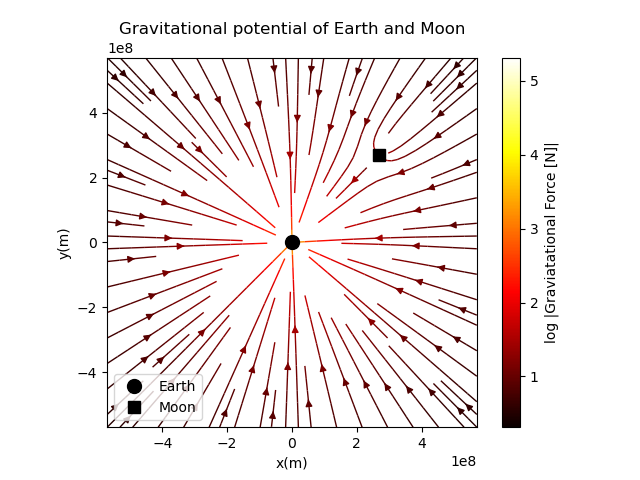

In [9]:
x = np.linspace(-1.5*dem,1.5*dem,250)
y = np.linspace(-1.5*dem,1.5*dem,250)

X, Y = np.meshgrid(x, y)

# Earth force
Fxe, Fye = Force(m_e, maplo, 0, 0, X, Y)

# Moon force
Fxm, Fym = Force(m_m, maplo, dem/np.sqrt(2), dem/np.sqrt(2), X, Y)

# total force
Fxtot = Fxe + Fxm
Fytot = Fye + Fym

magnitude = np.sqrt(Fxtot**2 + Fytot**2)

fig4, ax2 = plt.subplots()

stream = ax2.streamplot(
    X, Y,
    Fxtot, Fytot,
    color=np.log10(magnitude + 1e-9), # let epsilon = 1e-9 to prevent log(0) 
    linewidth=1,
    cmap='hot'
)

ax2.plot(0, 0, 'ko', markersize=10, label='Earth')
ax2.plot(dem/np.sqrt(2), dem/np.sqrt(2), 'ks', markersize=8, label='Moon')

ax2.legend(loc="lower left")
ax2.set_aspect("equal")

cbar = fig4.colorbar(stream.lines)
cbar.set_label("log |Graviatational Force [N]|")

# axis labels and title
ax2.set_title("Gravitational potential of Earth and Moon")
ax2.set_xlabel("x(m)")
ax2.set_ylabel("y(m)")

plt.show()

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

### Derivation of the Earth–Moon Balance Point

The gravitational force exerted by a body of mass $M$ on a mass $m$ at distance $r$ is

$$
F = G \frac{Mm}{r^2}
$$

At the balance point between the Earth and the Moon, the magnitudes of the gravitational forces are equal:

$$
|\vec{F}_{earth}| = |\vec{F}_{moon}|
$$

Therefore,

$$
G \frac{M_E m}{r_E^2} = G \frac{M_M m}{r_M^2}
$$
where $r_E$ is the distance from earth to the balance point and $r_M$ is from the moon to the balance point.

Canceling the constants $G$ and $m$:

$$
\frac{M_E}{r_E^2} = \frac{M_M}{r_M^2}
$$

Taking the square root of both sides:

$$
\frac{r_E}{r_M} = \sqrt{\frac{M_E}{M_M}}
$$

Since the balance point lies along the Earth–Moon line,

$$
r_E + r_M = d_{EM}
$$

Substitute

$$
r_E = d_{EM} - r_M
$$

into the ratio equation:

$$
\frac{d_{EM} - r_M}{r_M} = \sqrt{\frac{M_E}{M_M}}
$$

Solving for $r_M$:

$$
d_{EM} - r_M = r_M\sqrt{\frac{M_E}{M_M}}
$$

$$
d_{EM} = r_M\left(1 + \sqrt{\frac{M_E}{M_M}}\right)
$$

Therefore,

$$
r_M = \frac{d_{EM}}{1 + \sqrt{\frac{M_E}{M_M}}}
$$

and

$$
r_E = d_{EM} - r_M
$$

Because the Earth–Moon line lies along the direction

$$
\left(\frac{d_{EM}}{\sqrt{2}},\frac{d_{EM}}{\sqrt{2}}\right),
$$

the coordinates of the balance point are

$$
x = \frac{r_E}{\sqrt{2}}, \qquad y = \frac{r_E}{\sqrt{2}}
$$
$$ (\frac{r_E}{\sqrt{2}},\frac{r_E}{\sqrt{2}})$$

And your updated plot, including the balance point, goes in the cell below.

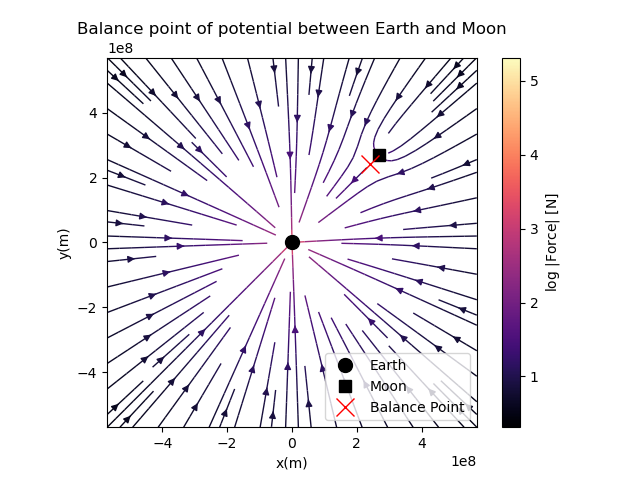

In [10]:
fig5, ax = plt.subplots()

stream = ax.streamplot(
    X, Y,
    Fxtot, Fytot,
    color=np.log10(magnitude),
    linewidth=1,
    cmap='magma'
)

# Earth
ax.plot(0, 0, 'ko', 
        markersize=10, 
        label='Earth')

# Moon
ax.plot(dem/np.sqrt(2), dem/np.sqrt(2), 'ks', 
        markersize=8, 
        label='Moon')

r_M = dem / (1 + np.sqrt(m_e/m_m))
r_E = dem - r_M 

x_balance = r_E/np.sqrt(2) 
y_balance = r_E/np.sqrt(2) 

# Balance point
ax.plot(x_balance, y_balance,
        'rx', markersize=13, 
        label='Balance Point')

ax.set_aspect("equal")

cbar = fig5.colorbar(stream.lines)
cbar.set_label(r"log |Force| $[\mathrm{N}]$")

ax.legend(loc="lower right")

# axis labels and title
ax.set_title("Balance point of potential between Earth and Moon")
ax.set_xlabel("x(m)")
ax.set_ylabel("y(m)")

plt.show()

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

From the calculation above, the distance of the balance point from the Earth is approximately

$$
r_E \approx 3.46 \times 10^8 \ \text{m}.
$$

The Earth–Moon distance is

$$
d_{EM} = 3.8 \times 10^8 \ \text{m}.
$$

Therefore, the distance from the Moon is

$$
r_M = d_{EM} - r_E.
$$

Substituting the numerical values,

$$
r_M \approx 3.8\times10^8 - 3.46\times10^8
$$

$$
r_M \approx 3.4 \times 10^7 \ \text{m}.
$$

Thus, the balance point is

- approximately $3.46\times10^8$ m from the Earth, and  
- approximately $3.4\times10^7$ m from the Moon.

This shows that the balance point is much closer to the Moon than to the Earth. In fact,

$$
\frac{r_E}{d_{EM}} \approx 0.91,
$$

so the balance point lies about $91\%$ of the way from the Earth to the Moon.

This result makes physical sense because the Earth is much more massive than the Moon:

$$
\frac{M_E}{M_M} \approx 81.
$$

Since the gravitational force scales as

$$
F \propto \frac{M}{r^2},
$$

the Moon must be significantly closer to the rocket in order for its weaker gravitational pull to balance the much stronger gravitational attraction of the Earth.

Therefore, the balance point lies near the Moon, where the Moon's gravitational force becomes comparable to that of the Earth.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.



1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [11]:
T = (m0 - mf)/mdot

print(T, "s")

157.69230769230768 s


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [12]:
def delta_v(t, m0, mf, mdot, ve, g):
    """
    Compute the rocket velocity change using Tsiolkovsky rocket equation

    Parameters 
    ----------
    t    : Time (s)
    m0   : Initial wet mass of the rocket (kg)
    mf   : Final dry mass of the rocket (kg)
    mdot : Fuel burn rate (kg/s)
    ve   : Exxhaust velocity (m/s) 
    g    : gravitational acceleration (m/s^2)

    Returns
    -------
    Change in velocity delta v(t)
    """

    if m0 <= 0 or mf <= 0:
        raise ValueError("Masses must be positive")
        
    if mf >= m0:
        raise ValueError("Dry mass must be less than wet mass")

    if mdot <= 0:
        raise ValueError("Burn rate must be positive")

    # Burn time T 
    T = (m0 - mf) / mdot 

    # mass at time t, m(t)
    m_t = m0 - mdot * t

    # change in velocity 
    dv = ve * np.log(m0 / m_t) - g*t

    # No veolicity change after burnout 
    dv = np.where(t > T, 0, dv)
    
    return dv

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [13]:
import scipy

h, err = scipy.integrate.quad(delta_v, 0, T, args=(m0, mf, mdot, ve, g))

print("Burn time:", T, "m/s")
print("Altitude at burnout:", h, "m")
print("Estimated error:", err)

Burn time: 157.69230769230768 m/s
Altitude at burnout: 74093.98013366401 m
Estimated error: 5.848811185394151e-08


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

Our calculated altitude is larger than the NASA test result of
approximately $70\ \text{km}$.

This difference is expected because the model makes several simplifying
assumptions. Most importantly, the calculation neglects atmospheric
drag. During launch, the rocket travels through the dense lower
atmosphere where drag forces are significant and remove a substantial
amount of kinetic energy from the rocket. Because drag is not included
in the model, our calculation overestimates the rocket’s velocity and
therefore predicts a higher altitude.

In addition, the model assumes constant gravitational acceleration $g$,
a constant fuel burn rate $\dot{m}$, and perfectly efficient thrust.
In reality, the burn rate can vary during flight, gravity decreases
slightly with altitude, and some energy is lost due to inefficiencies
in the propulsion system. The rocket also follows a slightly tilted
trajectory rather than moving purely vertically.

Overall, the model predicts values that are reasonably close to the
test results, and the differences can be explained by the simplifying
assumptions used in the calculation.